In [17]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.surf_score import calculate_surf_score
from src.analytics import (
    best_surf_times,
    get_beach_config,
    get_beach_data,
    get_beach_forecast,
)

In [18]:
df = pd.read_csv("../data/raw/marine_data.csv")

df.head()

,time,wave_height,wave_period,wave_direction,wind_wave_height,swell_wave_height,swell_wave_period,swell_wave_direction,wind_speed_10m,wind_direction_10m,beach_id,beach_name
0,2026-08-23T00:00,0.92,7.90,224,0.38,0.46,9.70,227,7.9,177,1,Máncora
1,2026-08-23T01:00,0.88,8.05,225,0.36,0.46,10.05,227,9.3,188,1,Máncora
2,2026-08-23T02:00,0.88,8.05,224,0.40,0.46,10.10,227,10.5,192,1,Máncora
3,2026-08-23T03:00,0.88,8.00,223,0.42,0.44,10.00,227,11.9,185,1,Máncora
4,2026-08-23T04:00,0.88,7.95,222,0.46,0.44,9.90,227,13.6,186,1,Máncora


In [19]:
beaches = pd.read_csv("../data/beaches.csv")

beaches = beaches.rename(columns={"id": "beach_id"})

beaches.head()

,beach_id,name,country,latitude,longitude,preferred_swell_direction_deg,swell_direction_tolerance_deg,preferred_wind_direction_deg,wind_direction_tolerance_deg
0,1,Máncora,Peru,-4.1078,-81.0475,315,45,112,45
1,2,Lobitos,Peru,-4.4553,-81.2808,225,45,112,45
2,3,Chicama,Peru,-7.8440,-79.1465,225,45,135,45
3,4,Huanchaco,Peru,-8.0810,-79.1200,180,90,157,45
4,5,Pacasmayo,Peru,-7.4015,-79.5710,225,45,45,45


In [20]:
df = df.merge(
    beaches[
        [
            "beach_id",
            "preferred_swell_direction_deg",
            "swell_direction_tolerance_deg",
            "preferred_wind_direction_deg",
            "wind_direction_tolerance_deg"
        ]
    ],
    on="beach_id",
    how="left"
)

df.head()

,time,wave_height,wave_period,wave_direction,wind_wave_height,swell_wave_height,swell_wave_period,swell_wave_direction,wind_speed_10m,wind_direction_10m,beach_id,beach_name,preferred_swell_direction_deg,swell_direction_tolerance_deg,preferred_wind_direction_deg,wind_direction_tolerance_deg
0,2026-08-23T00:00,0.92,7.90,224,0.38,0.46,9.70,227,7.9,177,1,Máncora,315,45,112,45
1,2026-08-23T01:00,0.88,8.05,225,0.36,0.46,10.05,227,9.3,188,1,Máncora,315,45,112,45
2,2026-08-23T02:00,0.88,8.05,224,0.40,0.46,10.10,227,10.5,192,1,Máncora,315,45,112,45
3,2026-08-23T03:00,0.88,8.00,223,0.42,0.44,10.00,227,11.9,185,1,Máncora,315,45,112,45
4,2026-08-23T04:00,0.88,7.95,222,0.46,0.44,9.90,227,13.6,186,1,Máncora,315,45,112,45


In [21]:
df["surf_score"] = df.apply(
    lambda row: calculate_surf_score(
        wave_height=row["wave_height"],
        wave_period=row["wave_period"],
        wind_speed=row["wind_speed_10m"],
        wave_direction=row["wave_direction"],
        preferred_swell_direction=row["preferred_swell_direction_deg"],
        wind_direction=row["wind_direction_10m"],
        preferred_wind_direction=row["preferred_wind_direction_deg"]
    ),
    axis=1
)

df[
    [
        "time",
        "beach_name",
        "wave_height",
        "wave_period",
        "wind_speed_10m",
        "wind_direction_10m",
        "surf_score"
    ]
].head(10)

,time,beach_name,wave_height,wave_period,wind_speed_10m,wind_direction_10m,surf_score
0,2026-08-23T00:00,Máncora,0.92,7.90,7.9,177,43.3
1,2026-08-23T01:00,Máncora,0.88,8.05,9.3,188,48.4
2,2026-08-23T02:00,Máncora,0.88,8.05,10.5,192,44.5
3,2026-08-23T03:00,Máncora,0.88,8.00,11.9,185,46.0
4,2026-08-23T04:00,Máncora,0.88,7.95,13.6,186,38.3
5,2026-08-23T05:00,Máncora,0.88,7.90,14.5,186,38.3
6,2026-08-23T06:00,Máncora,0.90,7.90,16.6,186,34.6
7,2026-08-23T07:00,Máncora,0.90,7.85,21.8,182,32.4
8,2026-08-23T08:00,Máncora,0.92,7.85,21.4,173,34.4
9,2026-08-23T09:00,Máncora,0.92,7.85,18.9,176,36.8


In [22]:
beach_scores = (
    df.groupby("beach_name")
    .agg(
        avg_surf_score=("surf_score", "mean"),
        max_surf_score=("surf_score", "max"),
        min_surf_score=("surf_score", "min")
    )
    .round(1)
    .sort_values("avg_surf_score", ascending=False)
)

beach_scores

,avg_surf_score,max_surf_score,min_surf_score
beach_name,,,
Huanchaco,74.3,85.7,65.7
Punta Rocas,67.9,85.5,54.8
Punta Hermosa,66.2,87.8,54.2
Cerro Azul,64.8,82.1,55.0
San Bartolo,62.7,79.5,54.2
Chicama,62.3,80.1,51.6
Punta Roquitas,61.0,71.3,53.2
Lobitos,53.1,62.7,42.3
Pacasmayo,45.1,52.8,34.8


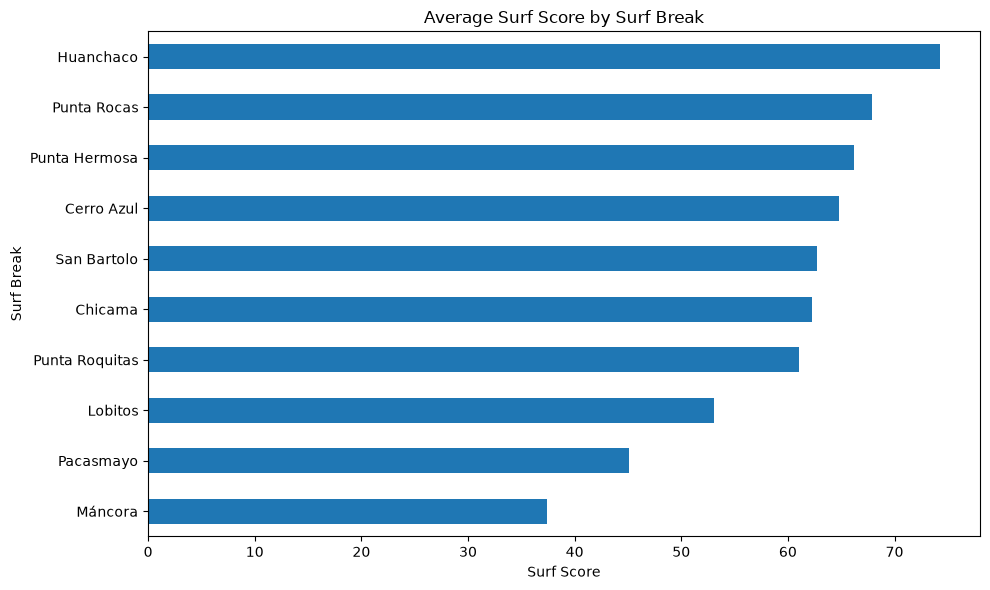

In [23]:
beach_scores["avg_surf_score"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(10, 6),
    title="Average Surf Score by Surf Break",
    xlabel="Surf Score",
    ylabel="Surf Break"
)

plt.tight_layout()
plt.show()

In [24]:
def plot_beach_directions(beach_name):
    beach = get_beach_data(df, beach_name)
    config = get_beach_config(beaches, beach_name)

    preferred_swell = config["preferred_swell_direction_deg"]
    preferred_wind = config["preferred_wind_direction_deg"]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)


    # Swell Direction
    axes[0].plot(
        beach["time"],
        beach["wave_direction"]
    )

    axes[0].axhline(
        y=preferred_swell,
        linestyle="--",
        label=f"Preferred Swell ({preferred_swell:.0f}°)"
    )

    axes[0].set_title(f"Swell Direction - {beach_name}")
    axes[0].set_ylabel("Direction (°)")
    axes[0].set_ylim(0, 360)
    axes[0].legend()

    # Wind Direction
    axes[1].plot(
        beach["time"],
        beach["wind_direction_10m"]
    )

    axes[1].axhline(
        y=preferred_wind,
        linestyle="--",
        label=f"Preferred Wind ({preferred_wind:.0f}°)"
    )

    axes[1].set_title(f"Wind Direction - {beach_name}")
    axes[1].set_ylabel("Direction (°)")
    axes[1].set_xlabel("Time")
    axes[1].set_ylim(0, 360)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [25]:
def plot_beach_conditions(beach_name):
    beach = get_beach_data(df, beach_name)

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # Surf Score
    axes[0].plot(
        beach["time"],
        beach["surf_score"]
    )

    axes[0].set_title(f"Surf Score - {beach_name}")
    axes[0].set_ylabel("Score")
    axes[0].set_ylim(0, 100)

    # Wave Height
    axes[1].plot(
        beach["time"],
        beach["wave_height"]
    )

    axes[1].set_title("Wave Height")
    axes[1].set_ylabel("Meters")

    # Wave Period
    axes[2].plot(
        beach["time"],
        beach["wave_period"]
    )

    axes[2].set_title("Wave Period")
    axes[2].set_ylabel("Seconds")
    axes[2].set_xlabel("Time")

    plt.tight_layout()
    plt.show()

In [26]:
def show_beach_analysis(beach_name):
    print("=" * 60)
    print(f"SURF ANALYSIS - {beach_name}")
    print("=" * 60)

    beach = get_beach_data(df, beach_name)
    config = get_beach_config(beaches, beach_name)

    print(f"\nAverage Surf Score: {beach['surf_score'].mean():.1f}")
    print(f"Best Surf Score: {beach['surf_score'].max():.1f}")
    print(f"Minimum Surf Score: {beach['surf_score'].min():.1f}")

    print("\nBeach Configuration:")
    print(f"Preferred Swell: {config['preferred_swell_direction_deg']:.0f}°")
    print(f"Preferred Wind: {config['preferred_wind_direction_deg']:.0f}°")

    print("\nBest Surf Times:")
    display(best_surf_times(df, beach_name))

    print("\nSurf Conditions:")
    plot_beach_conditions(beach_name)

    print("\nDirections:")
    plot_beach_directions(beach_name)

    print("\n72-Hour Forecast:")
    display(get_beach_forecast(df, beach_name))

In [27]:
import ipywidgets as widgets
from IPython.display import display

In [28]:
beach_selector = widgets.Dropdown(
    options=sorted(df["beach_name"].unique()),
    value="Punta Rocas",
    description="Surf Break:",
    style={"description_width": "initial"}
)

output = widgets.Output()

display(beach_selector)
display(output)

Dropdown(description='Surf Break:', index=7, options=('Cerro Azul', 'Chicama', 'Huanchaco', 'Lobitos', 'Máncor…

Output()

In [29]:
def update_beach_analysis(change):
    if change["name"] == "value":
        with output:
            output.clear_output(wait=True)
            show_beach_analysis(change["new"])

In [30]:
beach_selector.observe(
    update_beach_analysis,
    names="value"
)

SURF ANALYSIS - Punta Rocas

Average Surf Score: 67.9
Best Surf Score: 85.5
Minimum Surf Score: 54.8

Beach Configuration:
Preferred Swell: 225°
Preferred Wind: 90°

Best Surf Times:


,time,surf_score,wave_height,wave_period,wave_direction,wind_speed_10m,wind_direction_10m
0,2026-08-23T00:00,85.5,1.02,10.60,202,3.7,104
1,2026-08-25T06:00,84.0,1.12,10.05,202,5.7,101
2,2026-08-25T07:00,83.3,1.14,10.05,202,6.9,104
3,2026-08-25T05:00,81.5,1.12,10.05,202,6.4,112
4,2026-08-23T06:00,81.4,0.98,10.70,202,5.0,90



Surf Conditions:


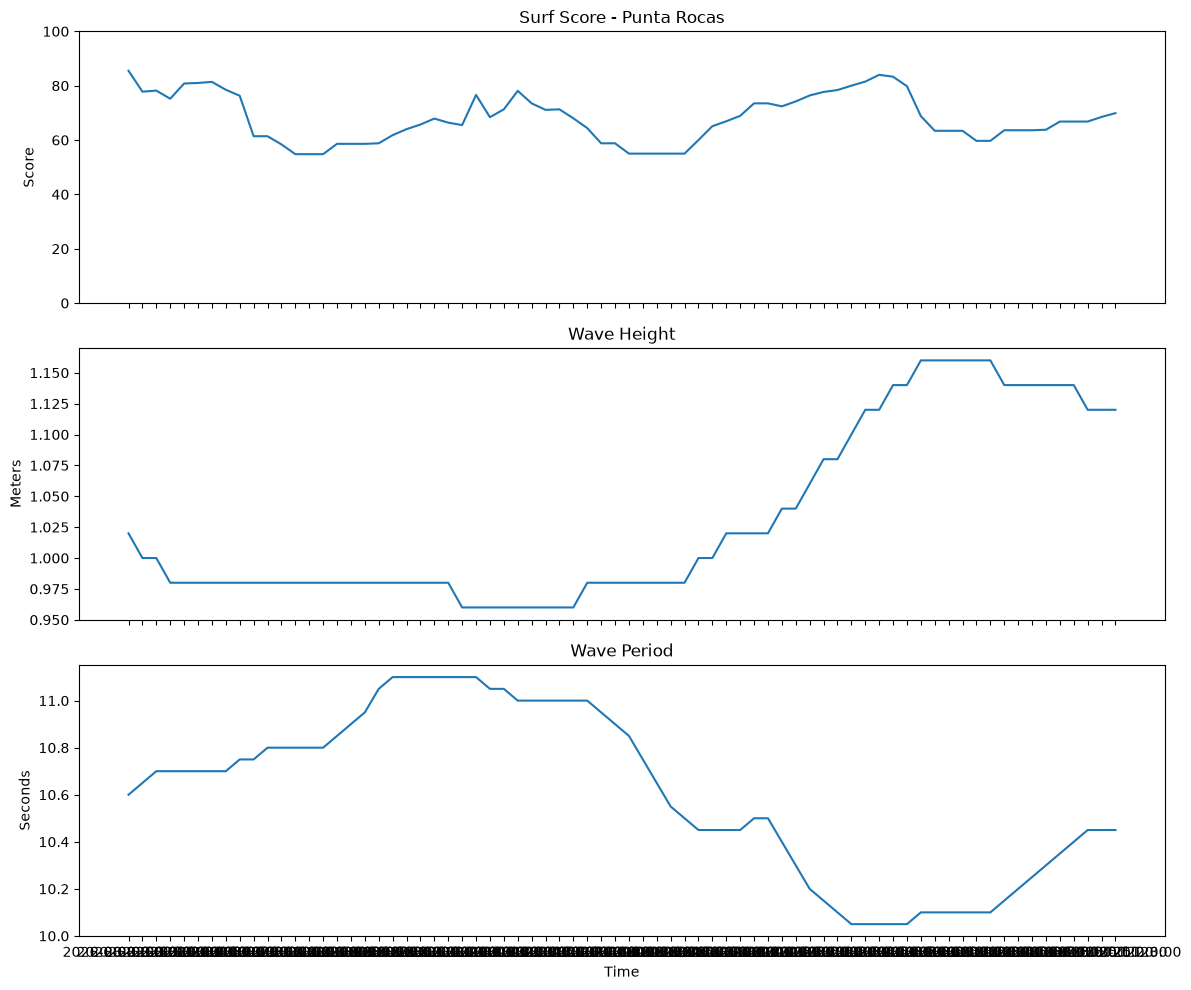


Directions:


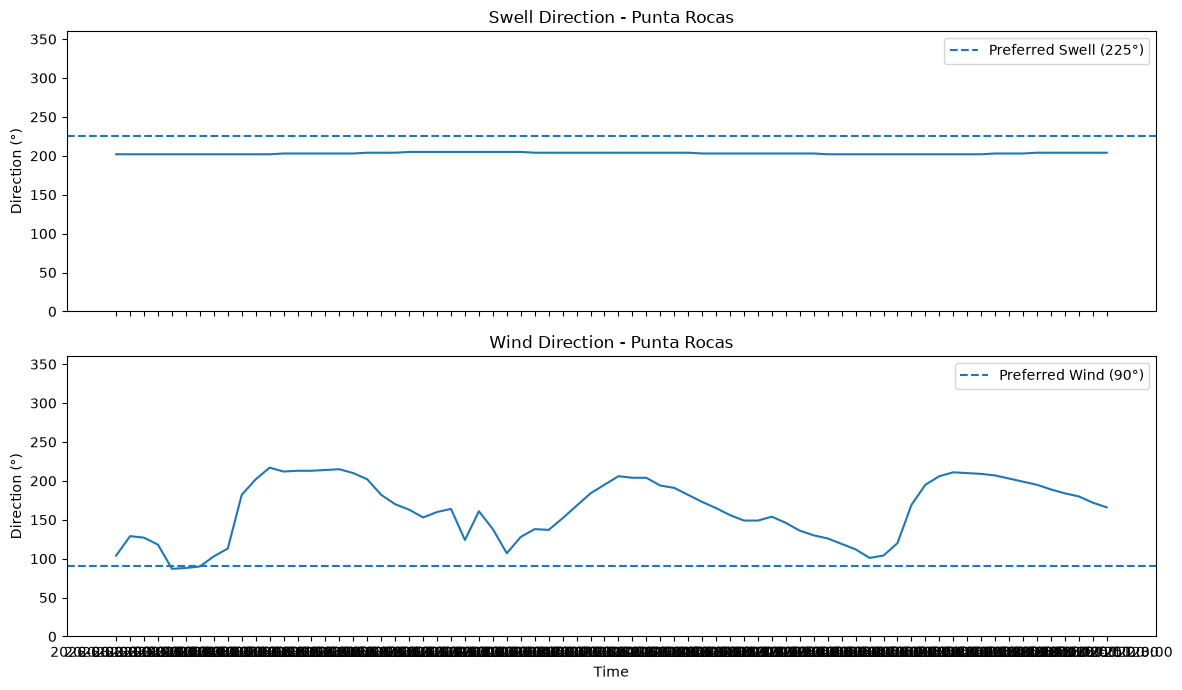


72-Hour Forecast:


,Time,Surf Score,Wave Height (m),Wave Period (s),Swell Direction (°),Wind Speed (km/h),Wind Direction (°)
0,2026-08-23T00:00,85.5,1.02,10.60,202,3.7,104
1,2026-08-23T01:00,77.8,1.00,10.65,202,8.6,129
2,2026-08-23T02:00,78.2,1.00,10.70,202,7.8,127
3,2026-08-23T03:00,75.2,0.98,10.70,202,6.9,118
4,2026-08-23T04:00,80.8,0.98,10.70,202,6.0,87
...,...,...,...,...,...,...,...
67,2026-08-25T19:00,66.8,1.14,10.35,204,9.6,189
68,2026-08-25T20:00,66.8,1.14,10.40,204,8.3,184
69,2026-08-25T21:00,66.8,1.12,10.45,204,7.2,180
70,2026-08-25T22:00,68.5,1.12,10.45,204,8.0,172


In [31]:
show_beach_analysis("Punta Rocas")